# Demonstration of `hii_region_model`
Bayesian kinematic distance calculator.

Trey Wenger, 2025

In [1]:
import pickle
import numpy as np
from scipy.stats import multivariate_normal
import pymc as pm
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt

from physiokinematic.hii_region_model import hii_region_model

In [2]:
# Load Reid et al. (2019) rotation curve parameters
with open("../../../data/reid19_params.pkl", "rb") as f:
    reid19_params = pickle.load(f)
print(reid19_params.keys())

samples = reid19_params['full'].resample(1_000)

# R0, Usun, Vsun, Wsun, a2, a3
samples = samples[np.array([0,1,2,3,6,7]), :]

reid19_fit = multivariate_normal.fit(samples.T)

dict_keys(['R0', 'Usun', 'Vsun', 'Wsun', 'Upec', 'Vpec', 'a2', 'a3', 'full'])


/tmp/ipykernel_331801/3720529096.py:3: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  reid19_params = pickle.load(f)


In [3]:
hii_data = pd.read_csv("../../../data/hii_data.csv")
data = hii_data.iloc[550].copy()
data

gname                   G035.126-00.755
glong                            35.126
glat                          -0.754265
radius                          169.392
vlsr                               34.5
e_vlsr                              0.1
line                              29.48
e_line                            0.204
line_unit                      mJy/beam
beam_area                   6893.719776
line_freq                        8000.0
fwhm                               19.7
e_fwhm                              0.2
te                                  NaN
e_te                              500.0
source                     WISE Catalog
author          Anderson et al. (2015b)
telescope                           GBT
kdar                                  N
Rgal                           6.567508
near                           2.055998
far                           11.270497
tangent                        6.676467
vlsr_tangent                  96.219351
plx                                 NaN


In [4]:
model = hii_region_model(
    data, # HII region data
    reid19_fit[0], # Prior mean on rotation curve parameters
    reid19_fit[1], # Prior covariance on rotation curve parameters
    prior_Rgal = 5.0, # Prior width on Galactocentric radius (kpc)
    prior_te_offset = [4500.0, 200.0], # Prior mean and width on electron temperature gradient offset (K)
    prior_te_slope = [360.0, 25.0], # Prior mean and width on elecron temperature gradient slope (K/kpc)
    prior_log10_q = [47.0, 2.0], # Prior mean and width on log10 ionizing photon rate (s-1)
    prior_log10_ne = [1.0, 2.0], # Prior mean and width on log10 electron density (cm-3)
    prior_kdar = [0.5, 0.5], # Prior shape for kinematic distance ambiguity resolution
    log10_radius_sigma = 0.1, # Apparent radius likelihood width
    log10_line_sigma = 0.2, # Line brightness likelihood width
    vlsr_sigma = 10.0, # Assumed LSR velocity systematic uncertainty (km/s)
    te_sigma = 500.0, # Assumed electron temperature systematic uncertainty (K)
)

In [5]:
model

        rotcurve ~ MultivariateNormal(f(), <constant>)
       Rgal_norm ~ Gamma(0.5, f())
  te_offset_norm ~ Normal(0, 1)
   te_slope_norm ~ Normal(0, 1)
         te_norm ~ Normal(0, 1)
          kdar_w ~ Categorical(<constant>)
    log10_q_norm ~ Normal(0, 1)
   log10_ne_norm ~ Normal(0, 1)
            Rgal ~ Deterministic(f(Rgal_norm, rotcurve))
       te_offset ~ Deterministic(f(te_offset_norm))
        te_slope ~ Deterministic(f(te_slope_norm))
              te ~ Deterministic(f(te_norm, te_offset_norm, te_slope_norm, Rgal_norm, rotcurve))
        distance ~ Deterministic(f(rotcurve, Rgal_norm))
    abs_distance ~ Deterministic(f(rotcurve, Rgal_norm))
         log10_q ~ Deterministic(f(log10_q_norm))
        log10_ne ~ Deterministic(f(log10_ne_norm))
        log10_Rs ~ Deterministic(f(log10_q_norm, log10_ne_norm))
        log10_em ~ Deterministic(f(log10_ne_norm, log10_q_norm))
 log10_radius_mu ~ Deterministic(f(log10_q_norm, log10_ne_norm, rotcurve, Rgal_norm))
  log10_tau_line ~ 

In [6]:
# sample prior predictive
with model:
    prior = pm.sample_prior_predictive(1_000)

Sampling: [Rgal_norm, kdar_w, log10_line_obs, log10_ne_norm, log10_q_norm, log10_radius_obs, rotcurve, te_norm, te_offset_norm, te_slope_norm, vlsr_obs]


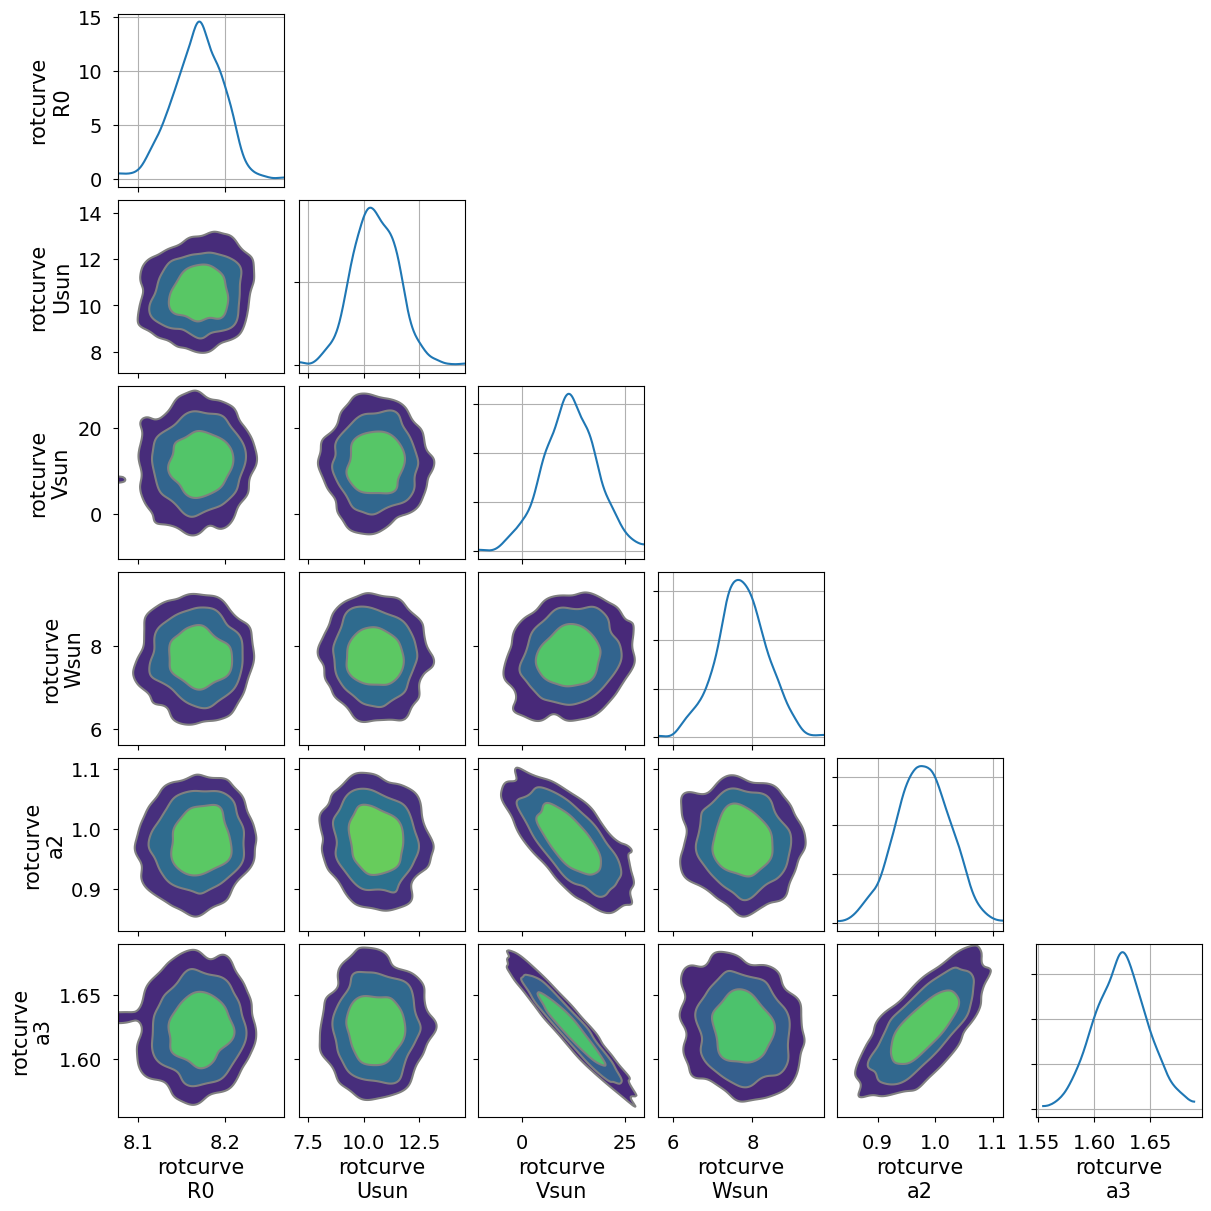

In [7]:
# plot prior samples
_ = pm.plot_pair(prior.prior["rotcurve"], marginals=True, figsize=(12, 12), kind='kde', backend_kwargs={"layout": "constrained"})

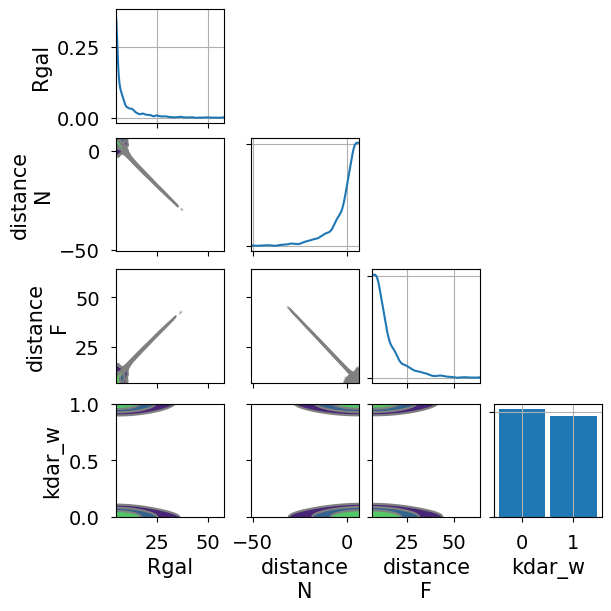

In [8]:
# plot prior samples
_ = pm.plot_pair(prior.prior, marginals=True, figsize=(6, 6), kind='kde', backend_kwargs={"layout": "constrained"}, var_names=["Rgal", "distance", "kdar_w"])

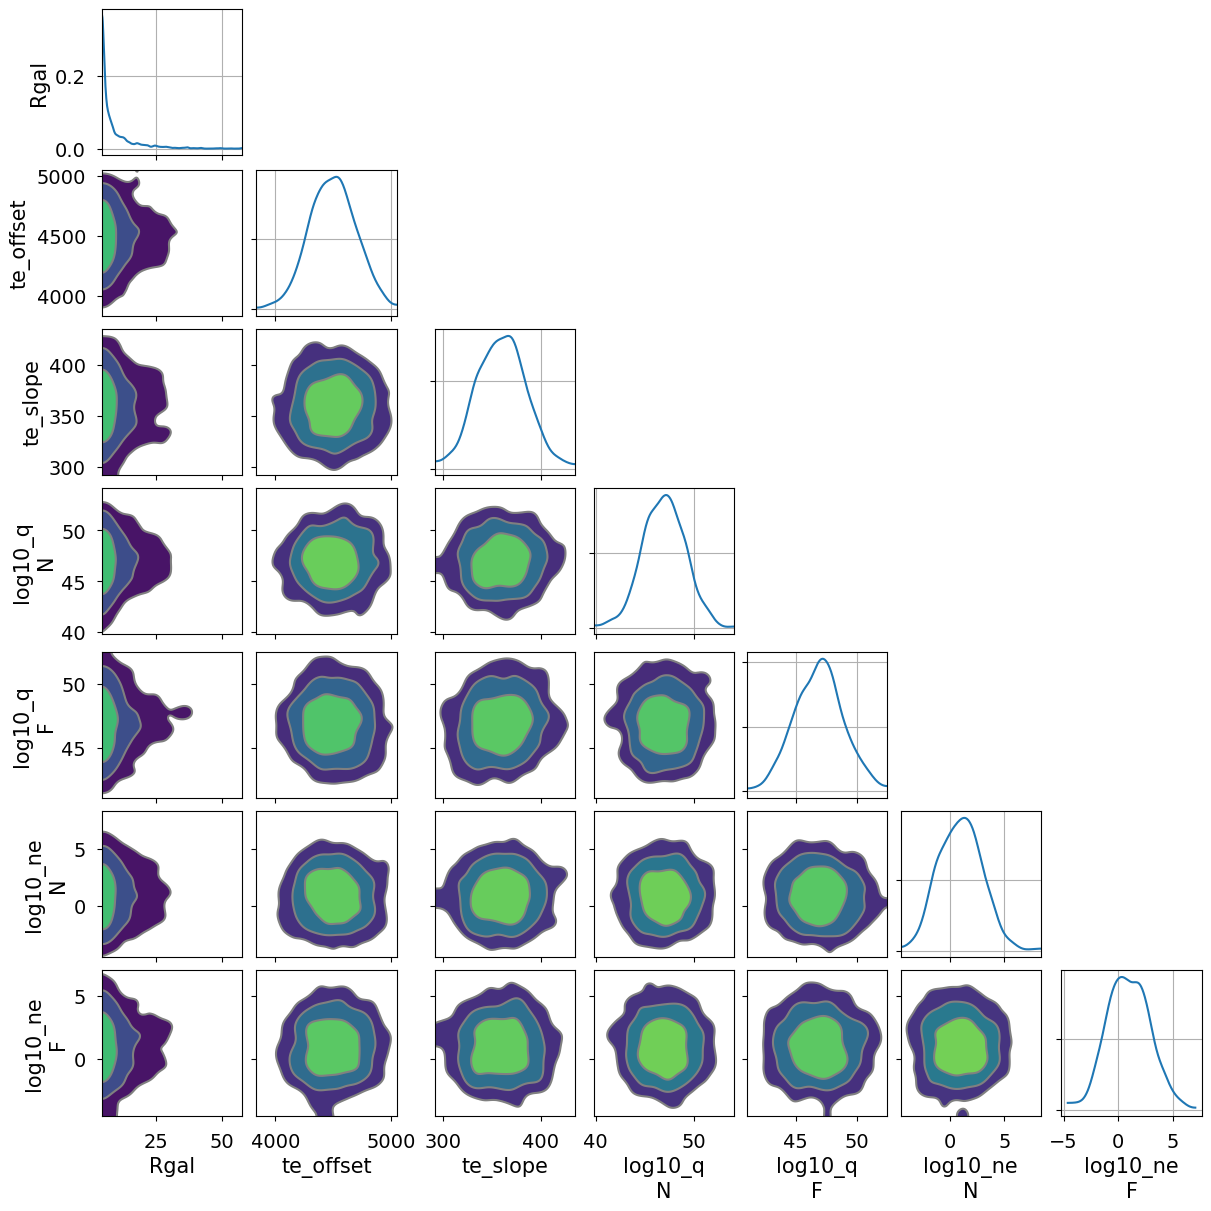

In [9]:
# plot prior samples
_ = pm.plot_pair(prior.prior, marginals=True, figsize=(12, 12), kind='kde', backend_kwargs={"layout": "constrained"}, var_names=["Rgal", "te_offset", "te_slope", "log10_q", "log10_ne"])

In [10]:
# The model is multi-modal, so we sample with SMC
with model:
    trace = pm.sample_smc()

Initializing SMC sampler...
Sampling 12 chains in 12 jobs


 |████████████████████████████████████████| 100.00% [100/100 00:00<?  Stage: 5 Beta: 1.000]

/home/twenger/miniforge3/envs/physiokinematic/lib/python3.12/site-packages/arviz/data/base.py:272: UserWarning: More chains (12) than draws (6). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


In [11]:
az.summary(trace, hdi_prob=0.68, var_names=["rotcurve", "Rgal", "distance", "kdar_w", "te_offset", "te_slope", "te", "log10_q", "log10_ne", "log10_Rs", "log10_em"])

,mean,sd,hdi_16%,hdi_84%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rotcurve[R0],8.169,0.027,8.142,8.195,0.000,0.000,4827.0,6154.0,1.00
rotcurve[Usun],10.472,1.000,9.516,11.500,0.014,0.010,5528.0,5232.0,1.00
rotcurve[Vsun],12.239,6.206,6.272,18.415,0.084,0.063,5542.0,6083.0,1.00
rotcurve[Wsun],7.729,0.603,7.141,8.346,0.009,0.006,4877.0,4900.0,1.00
rotcurve[a2],0.977,0.044,0.937,1.024,0.001,0.000,5032.0,5156.0,1.00
rotcurve[a3],1.622,0.023,1.600,1.645,0.000,0.000,5711.0,4945.0,1.00
Rgal,6.575,0.443,6.133,6.992,0.005,0.003,7061.0,9005.0,1.00
distance[N],2.106,0.640,1.521,2.763,0.008,0.005,7007.0,9323.0,1.00
distance[F],11.256,0.639,10.621,11.860,0.008,0.005,7058.0,9015.0,1.00
kdar_w,0.666,0.471,0.000,1.000,0.008,0.003,3457.0,3457.0,1.01


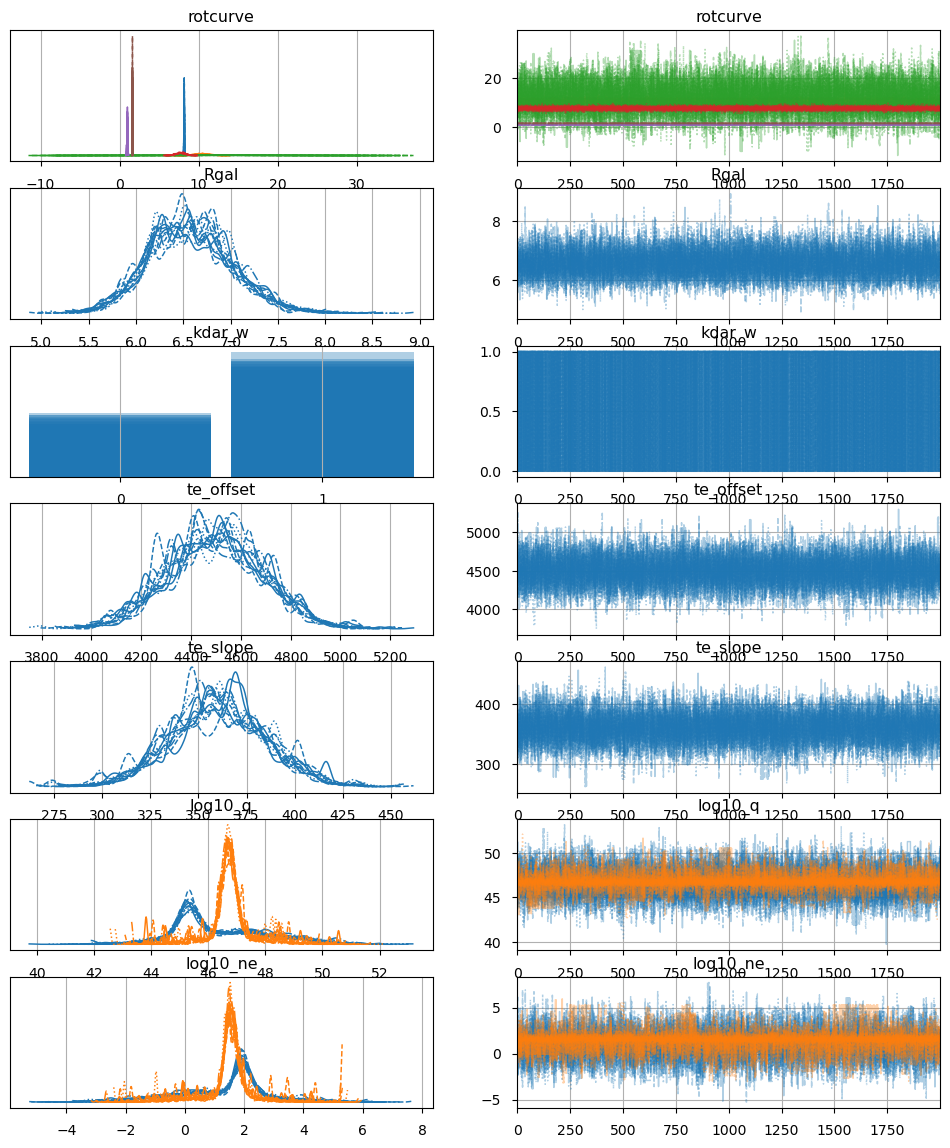

In [12]:
_ = pm.plot_trace(trace.posterior, var_names=["rotcurve", "Rgal", "kdar_w", "te_offset", "te_slope", "log10_q", "log10_ne"])

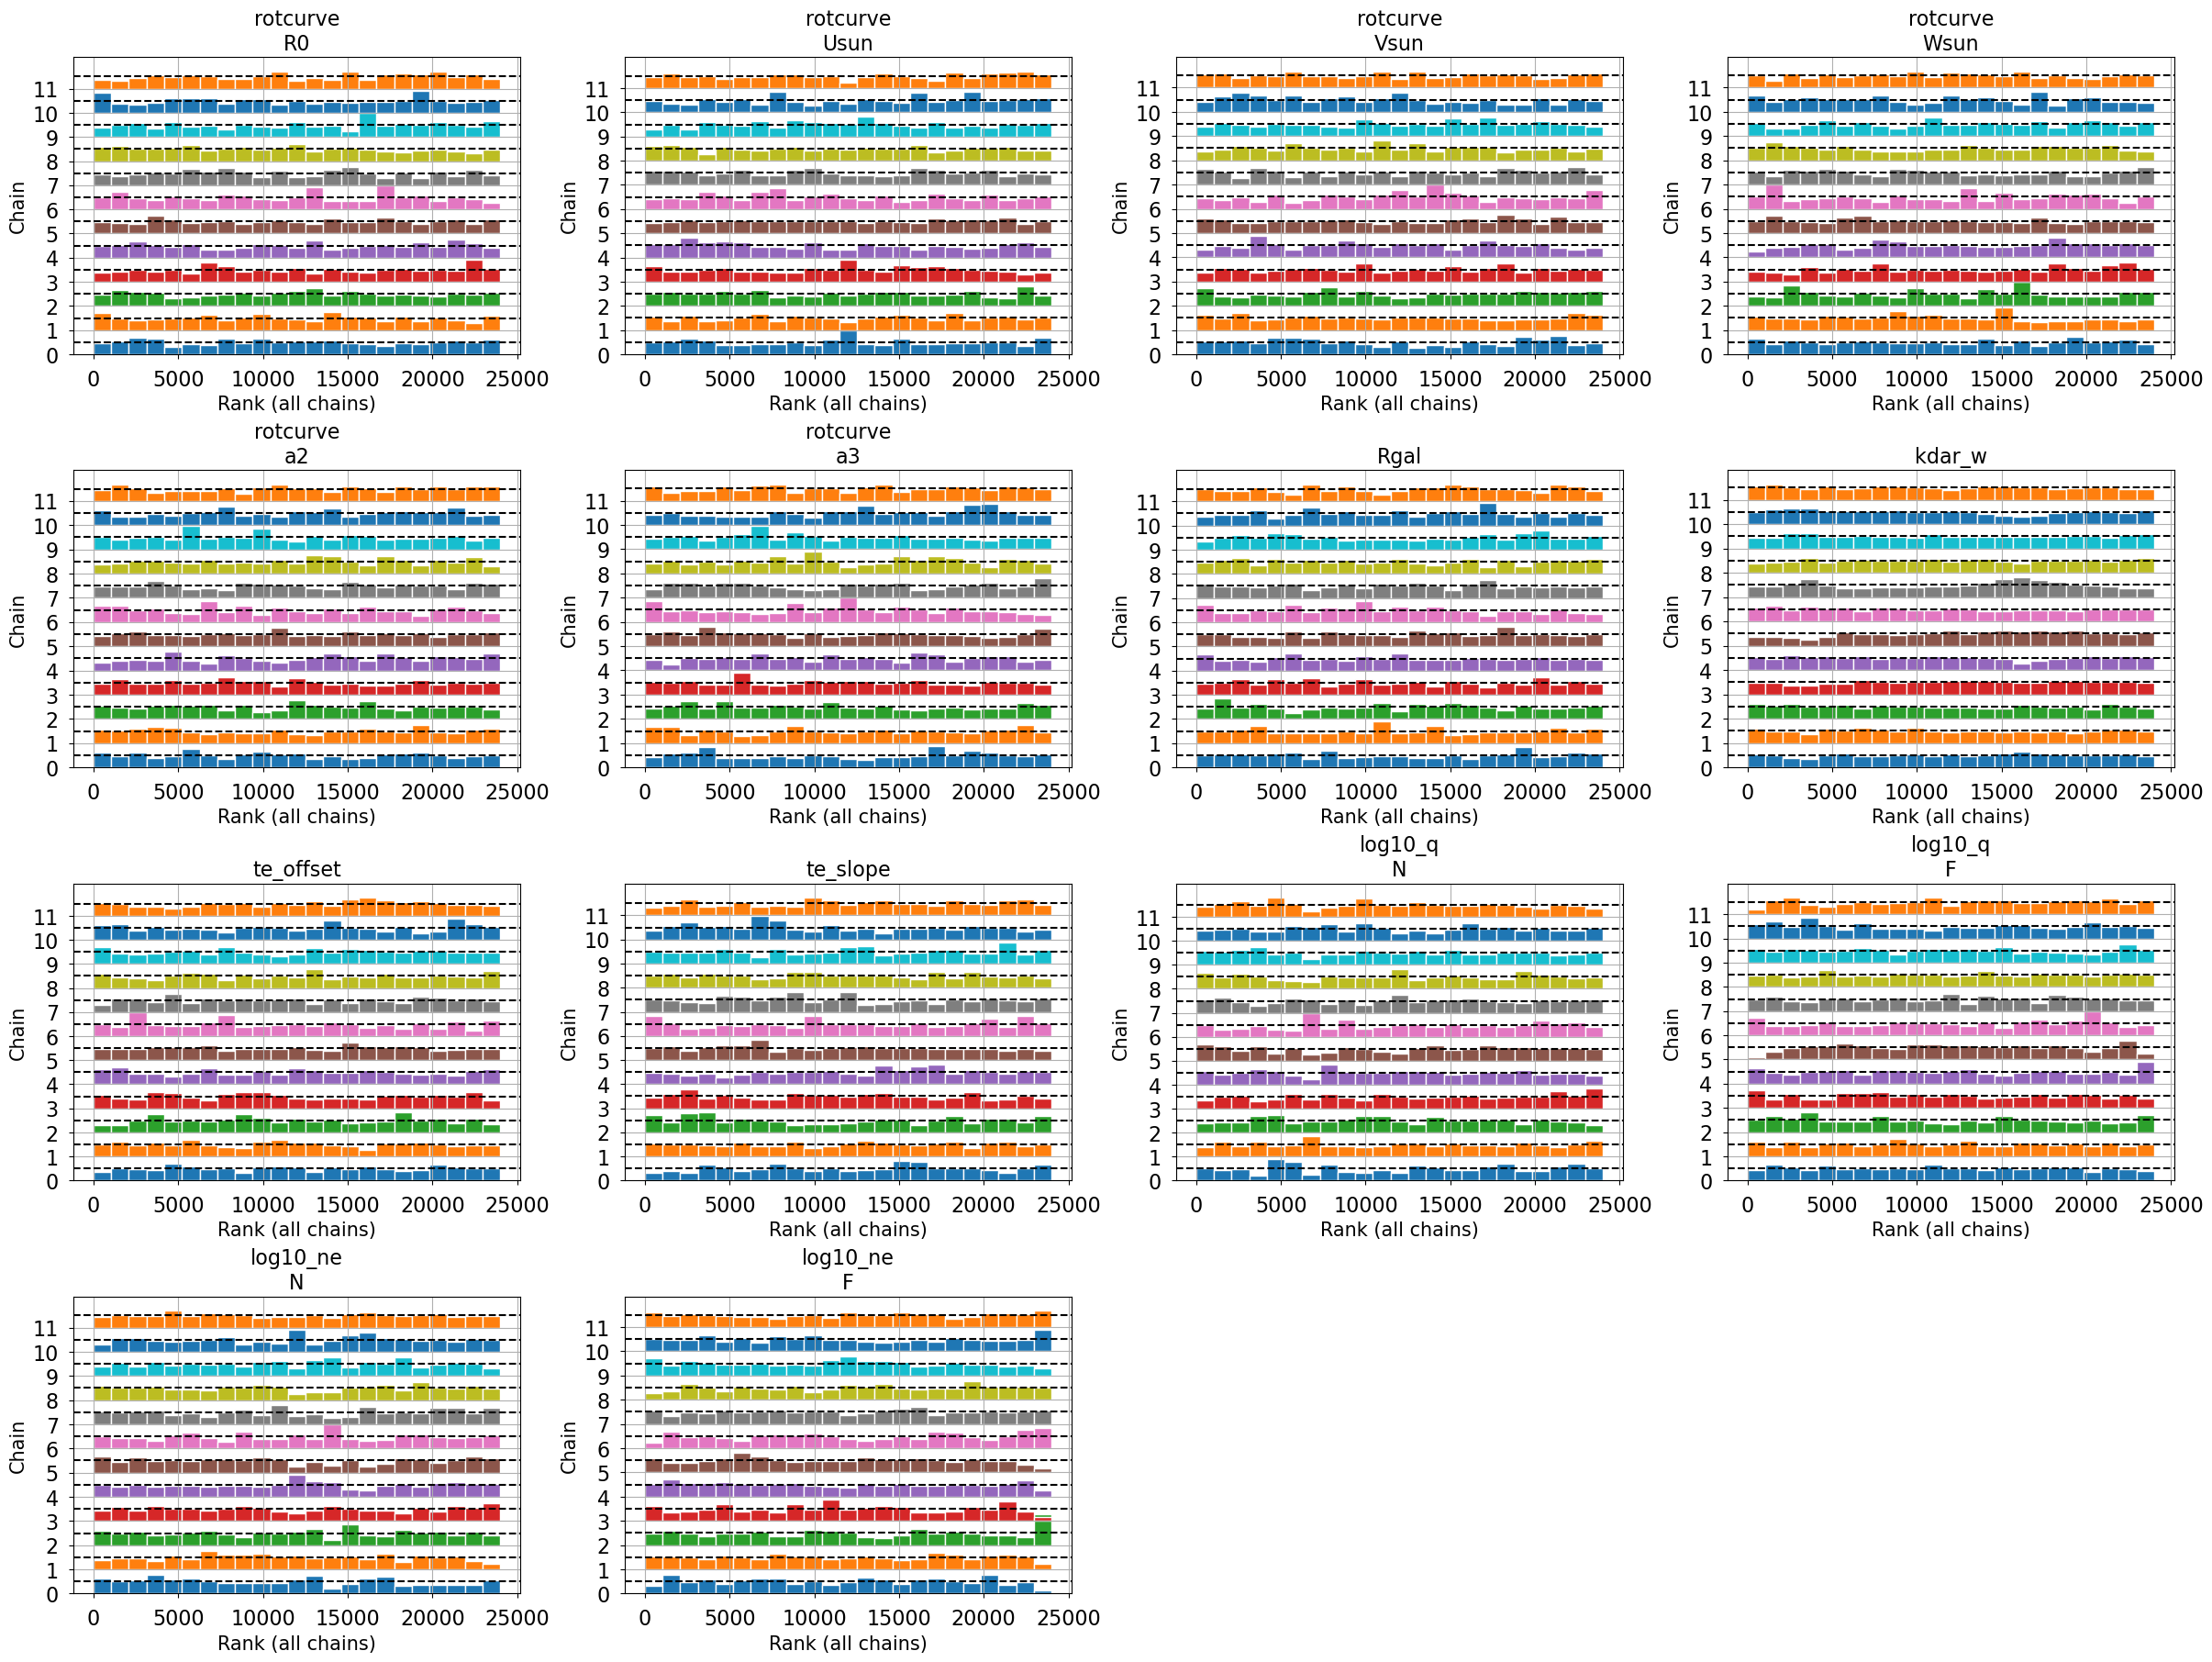

In [13]:
_ = pm.plot_rank(trace.posterior, var_names=["rotcurve", "Rgal", "kdar_w", "te_offset", "te_slope", "log10_q", "log10_ne"], figsize=(24, 18), backend_kwargs={"layout": "constrained"})

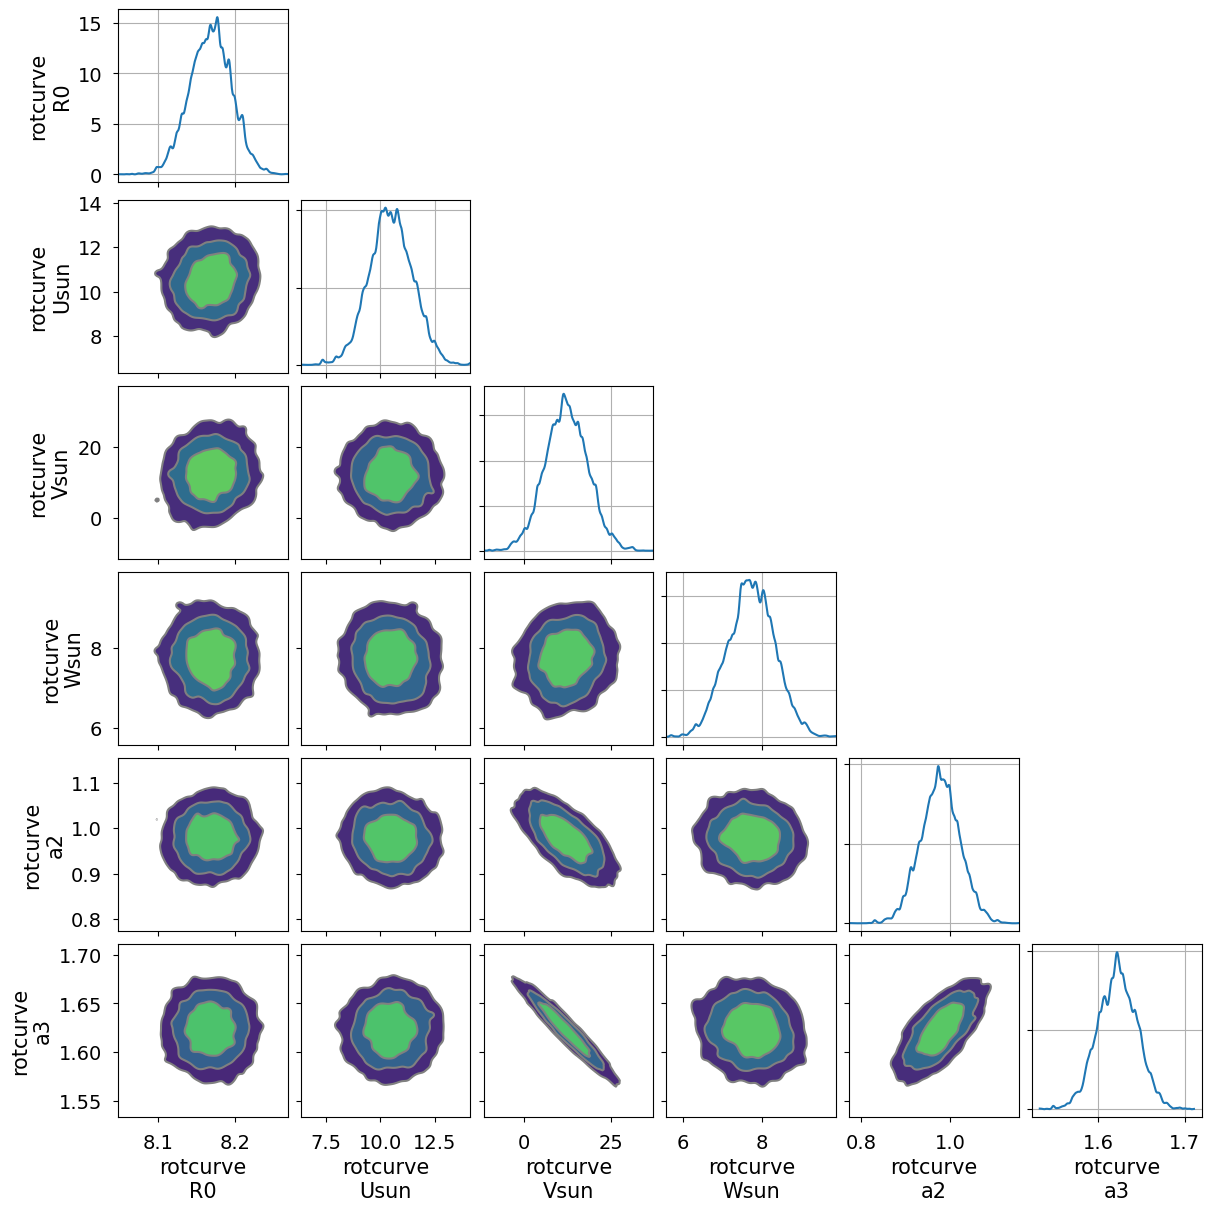

In [14]:
# plot posterior samples
_ = pm.plot_pair(trace.posterior["rotcurve"], marginals=True, figsize=(12, 12), kind='kde', backend_kwargs={"layout": "constrained"})

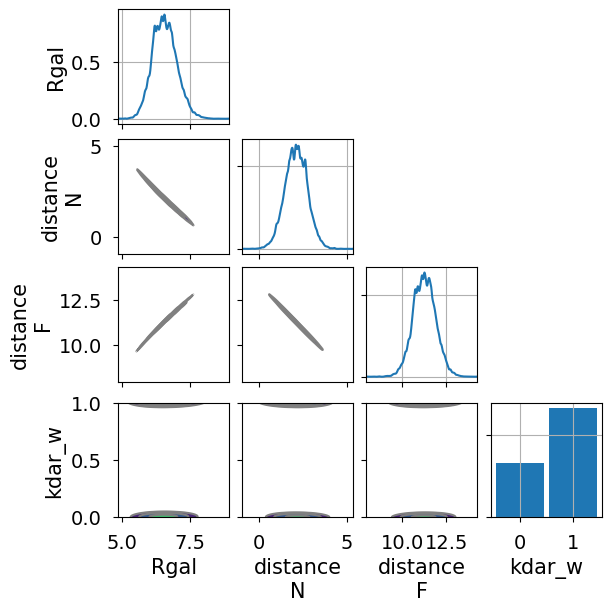

In [15]:
# plot posterior samples
_ = pm.plot_pair(trace.posterior, marginals=True, figsize=(6, 6), kind='kde', backend_kwargs={"layout": "constrained"}, var_names=["Rgal", "distance", "kdar_w"])

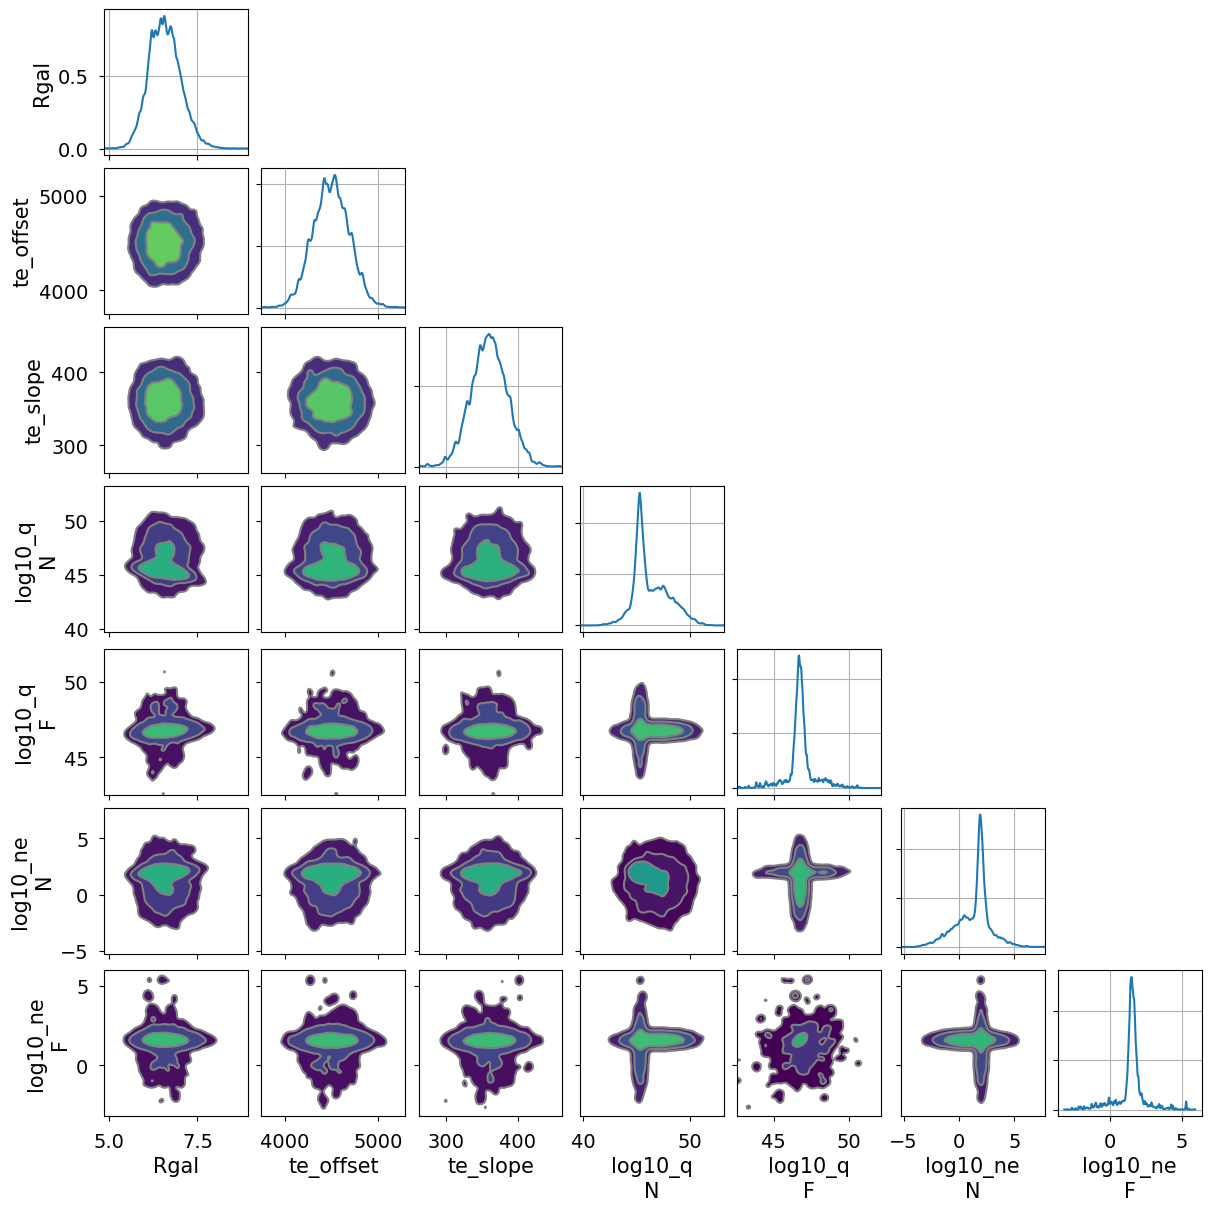

In [16]:
# plot posterior samples
_ = pm.plot_pair(trace.posterior, marginals=True, figsize=(12, 12), kind='kde', backend_kwargs={"layout": "constrained"}, var_names=["Rgal", "te_offset", "te_slope", "log10_q", "log10_ne"])

In [17]:
# sample posterior predictive
with model:
    posterior = pm.sample_posterior_predictive(trace.sel(draw=slice(None, None, 1)))

Sampling: [log10_line_obs, log10_radius_obs, vlsr_obs]


In [18]:
# drop samples with distance <= 0.0
bad_distance = trace.posterior["distance"] <= 0.0

result = {}

# Hyperparameters & distance-independent parameters
params = ["te_offset", "te_slope", "Rgal", "te"]
for param in params:
    if param not in trace.posterior:
        continue
    post = trace.posterior[param].data.flatten()
    result[f"{param}_mean"] = np.mean(post)
    result[f"{param}_std"] = np.std(post)
    result[f"{param}_median"] = np.median(post)
    hdi = az.hdi(post, hdi_prob=0.90)
    result[f"{param}_hdi5"] = hdi[0]
    result[f"{param}_hdi95"] = hdi[1]

# Distance-dependent parameters
params = [
    "distance",
    "log10_q",
    "log10_ne",
    "log10_Rs",
    "log10_em",
    "log10_tau_line",
    "log10_radius_mu",
    "log10_line_mu",
]
for param in params:
    posterior_N = trace.posterior[param].sel(kdar="N").data[
        (trace.posterior["kdar_w"] == 0) * (~bad_distance.sel(kdar="N"))
    ]
    posterior_F = trace.posterior[param].sel(kdar="F").data[
        (trace.posterior["kdar_w"] == 1) * (~bad_distance.sel(kdar="F"))
    ]
    posterior_T = np.concatenate([posterior_N, posterior_F])
    for kdar, post in zip(["N", "F", "T"], [posterior_N, posterior_F, posterior_T]):
        if len(post) < 5:
            continue
        result[f"{param}_{kdar}_mean"] = np.mean(post)
        result[f"{param}_{kdar}_std"] = np.std(post)
        result[f"{param}_{kdar}_median"] = np.median(post)
        hdi = az.hdi(post, hdi_prob=0.90)
        result[f"{param}_{kdar}_hdi5"] = hdi[0]
        result[f"{param}_{kdar}_hdi95"] = hdi[1]

    result[f"{param}_samples"] = posterior_T

# KDAR weight
result["kdar_w"] = len(posterior_F)/len(posterior_T)

# Observed parameters
params = [
    "vlsr_obs",
    "log10_radius_obs",
    "log10_line_obs",
]
for param in params:
    post = posterior.posterior_predictive[param].data.flatten()
    result[f"{param}_mean"] = np.mean(post)
    result[f"{param}_std"] = np.std(post)
    result[f"{param}_median"] = np.median(post)
    hdi = az.hdi(post, hdi_prob=0.90)
    result[f"{param}_hdi5"] = hdi[0]
    result[f"{param}_hdi95"] = hdi[1]
    result[f"{param}_samples"] = post

Text(0.5, 0, '$R$ (kpc)')

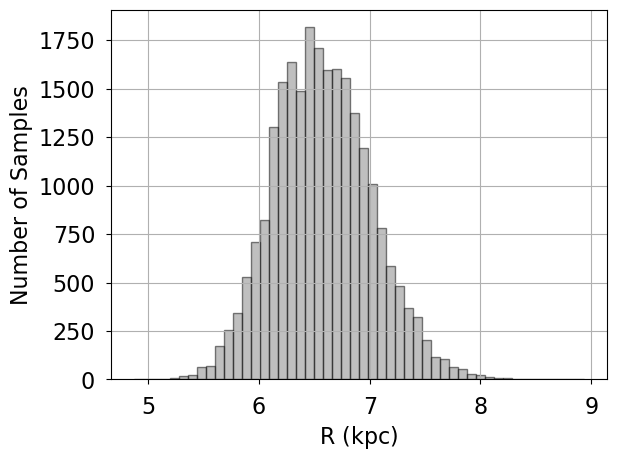

In [19]:
fig, ax = plt.subplots()
ax.hist(trace.posterior["Rgal"].data.flatten(), bins=50, color="gray", edgecolor="k", alpha=0.5)
ax.set_ylabel("Number of Samples")
ax.set_xlabel("$R$ (kpc)")

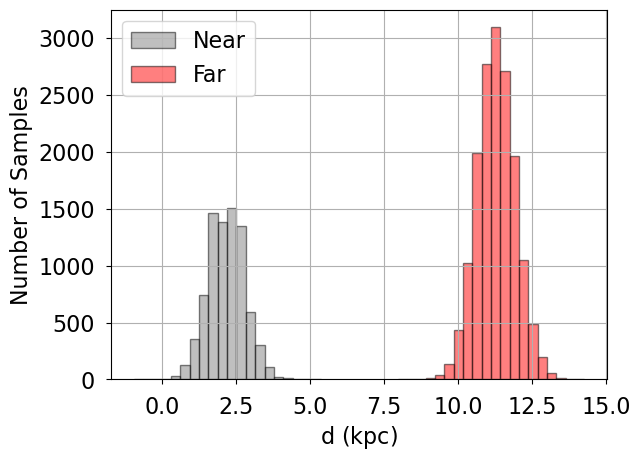

In [20]:
fig, ax = plt.subplots()
bins=20
ax.hist(trace.posterior["distance"].sel(kdar='N').data.flatten(), weights=(1-trace.posterior["kdar_w"].data.flatten()), bins=bins, color="gray", edgecolor="k", alpha=0.5, label="Near")
ax.hist(trace.posterior["distance"].sel(kdar='F').data.flatten(), weights=trace.posterior["kdar_w"].data.flatten(), bins=bins, color="red", edgecolor="k", alpha=0.5, label="Far")
ax.set_ylabel("Number of Samples")
ax.set_xlabel("$d$ (kpc)")
ax.legend(loc="best")

Text(0.5, 0, '$d$ (kpc)')

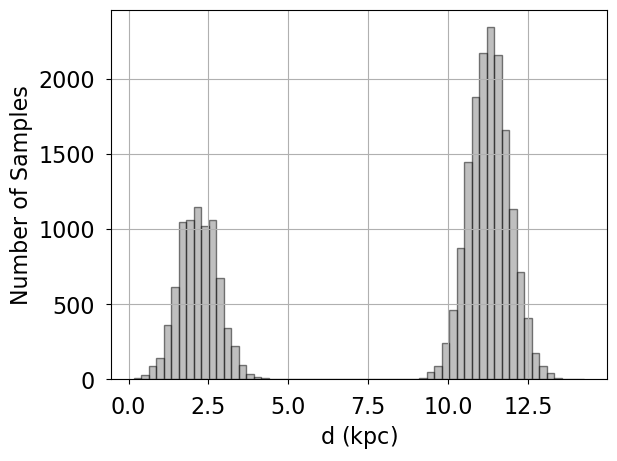

In [21]:
fig, ax = plt.subplots()
bins=60
ax.hist(result["distance_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.set_ylabel("Number of Samples")
ax.set_xlabel("$d$ (kpc)")

In [22]:
print(result["kdar_w"])

0.6665555462955246


Text(0.5, 0, '$\\log_{10} q$ (s$^{-1}$)')

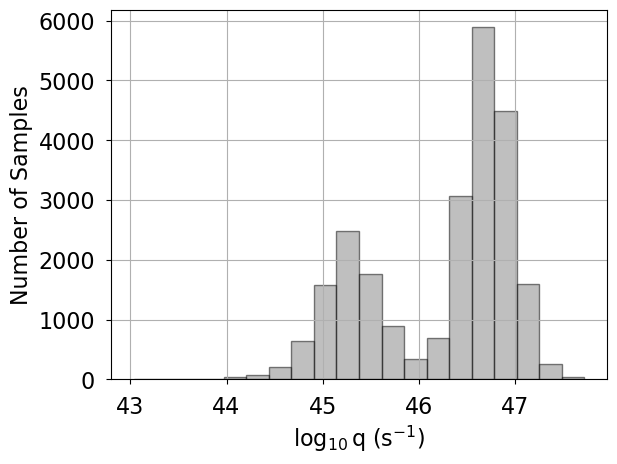

In [23]:
fig, ax = plt.subplots()
bins=20
ax.hist(result["log10_q_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.set_ylabel("Number of Samples")
ax.set_xlabel(r"$\log_{10} q$ (s$^{-1}$)")

Text(0.5, 0, '$\\log_{10} n_e$ (cm$^{-3}$)')

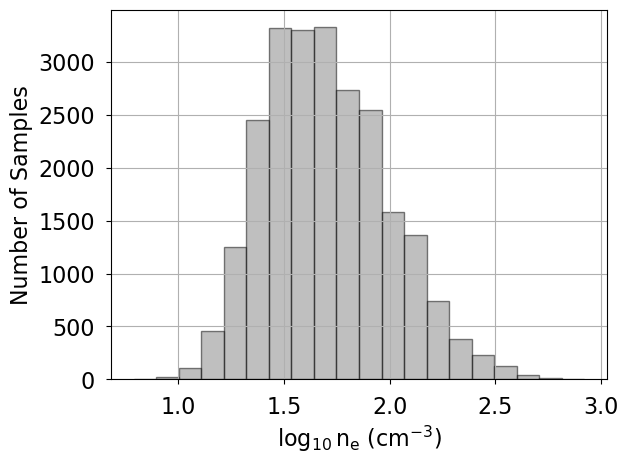

In [24]:
fig, ax = plt.subplots()
bins=20
ax.hist(result["log10_ne_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.set_ylabel("Number of Samples")
ax.set_xlabel(r"$\log_{10} n_e$ (cm$^{-3}$)")

Text(0.5, 0, '$\\log_{10} EM$ (pc cm$^{-6}$)')

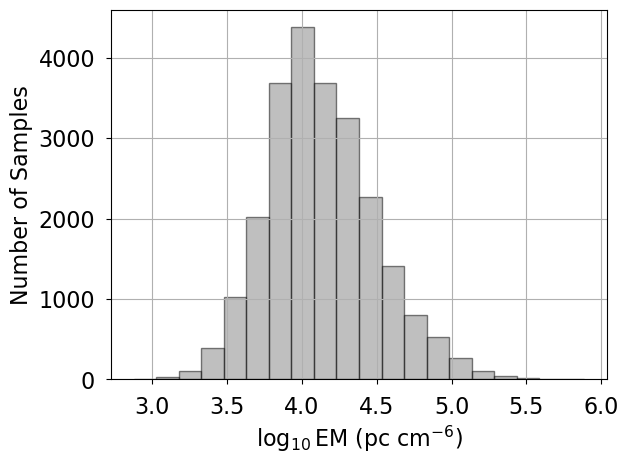

In [25]:
fig, ax = plt.subplots()
bins=20
ax.hist(result["log10_em_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.set_ylabel("Number of Samples")
ax.set_xlabel(r"$\log_{10} EM$ (pc cm$^{-6}$)")

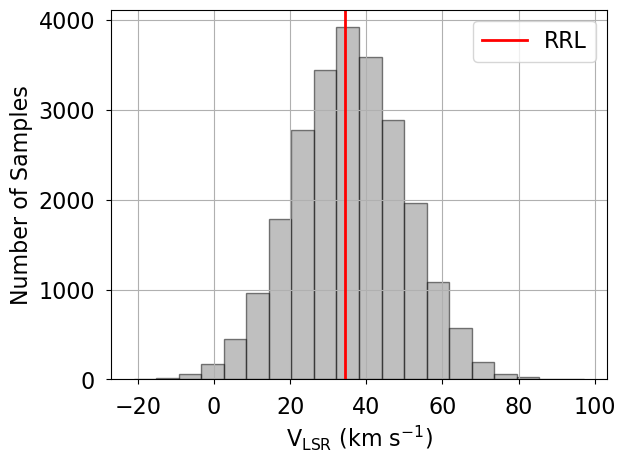

In [26]:
# plot posterior predictive samples
fig, ax = plt.subplots()
bins=20
ax.hist(result["vlsr_obs_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.axvline(data["vlsr"], color="r", lw=2, label="RRL")
ax.set_ylabel("Number of Samples")
ax.set_xlabel(r"$V_{\rm LSR}$ (km s$^{-1}$)")
ax.legend(loc="best")

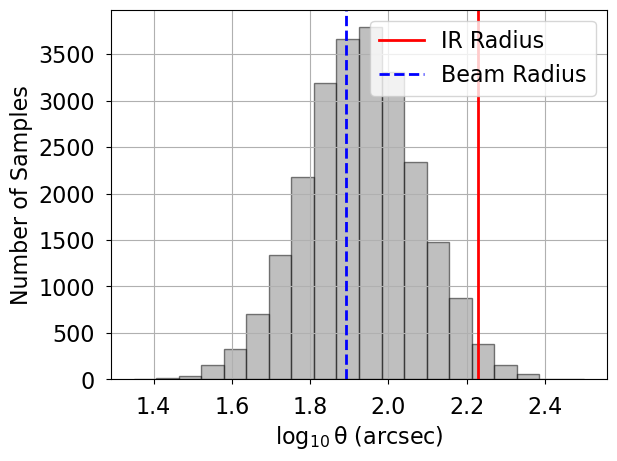

In [27]:
# plot posterior predictive samples
fig, ax = plt.subplots()
bins=20
ax.hist(result["log10_radius_obs_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.axvline(np.log10(data["radius"]), color="r", lw=2, label="IR Radius")
beam_radius = np.sqrt(data["beam_area"]*4.0*np.log(2.0)/np.pi)
ax.axvline(np.log10(beam_radius), color="b", lw=2, ls="--", label="Beam Radius")
ax.set_ylabel("Number of Samples")
ax.set_xlabel(r"$\log_{10} \theta$ (arcsec)")
ax.legend(loc="best")

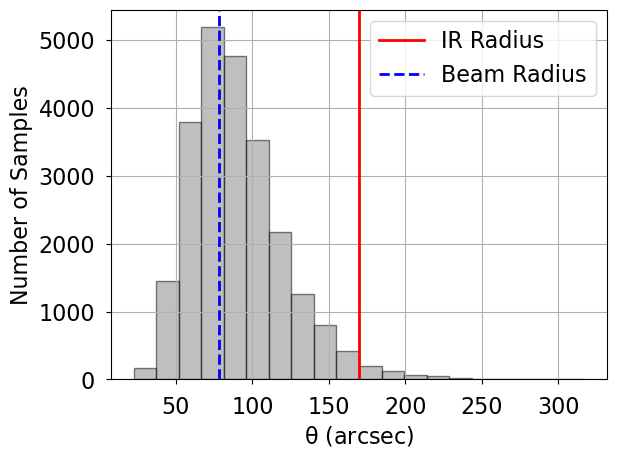

In [28]:
# plot posterior predictive samples
fig, ax = plt.subplots()
bins=20
ax.hist(10.0**result["log10_radius_obs_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.axvline(data["radius"], color="r", lw=2, label="IR Radius")
beam_radius = np.sqrt(data["beam_area"]*4.0*np.log(2.0)/np.pi)
ax.axvline(beam_radius, color="b", lw=2, ls="--", label="Beam Radius")
ax.set_ylabel("Number of Samples")
ax.set_xlabel(r"$\theta$ (arcsec)")
ax.legend(loc="best")

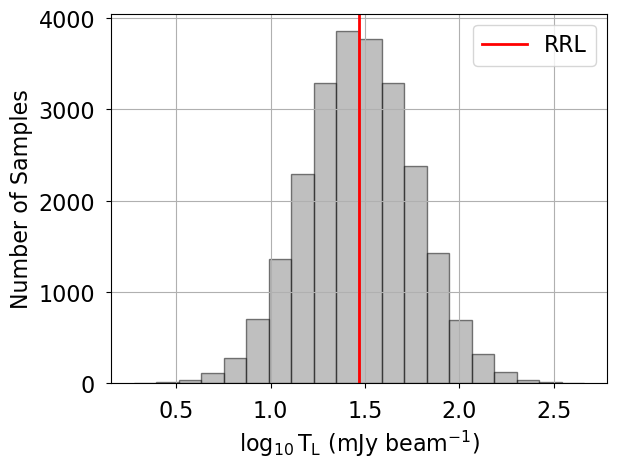

In [29]:
# plot posterior predictive samples
fig, ax = plt.subplots()
bins=20
ax.hist(result["log10_line_obs_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.axvline(np.log10(data["line"]), color="r", lw=2, label="RRL")
ax.set_ylabel("Number of Samples")
ax.set_xlabel(r"$\log_{10} T_L$ (mJy beam$^{-1}$)")
ax.legend(loc="best")

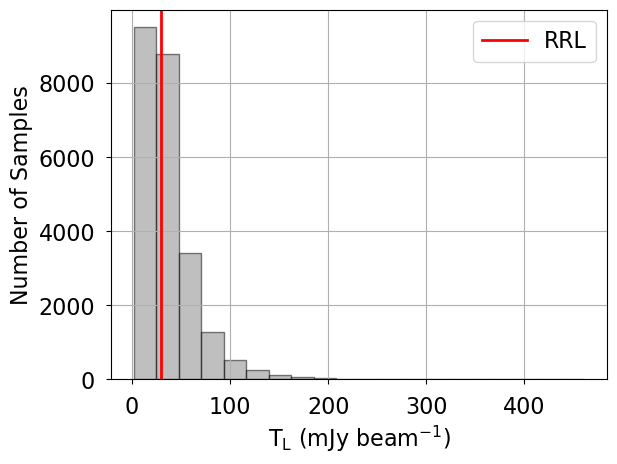

In [30]:
# plot posterior predictive samples
fig, ax = plt.subplots()
bins=20
ax.hist(10.0**result["log10_line_obs_samples"], bins=bins, color="gray", edgecolor="k", alpha=0.5)
ax.axvline(data["line"], color="r", lw=2, label="RRL")
ax.set_ylabel("Number of Samples")
ax.set_xlabel(r"$T_L$ (mJy beam$^{-1}$)")
ax.legend(loc="best")